In [227]:
from jitcdde import t
from toyParameters import *
import numpy as np
import matplotlib.pyplot as plt
from msrDynamics import Node, System

plt.rc("xtick", labelsize=16, top=True, direction="in")
plt.rc("ytick", labelsize=16, right=True, direction="in")
plt.rc("axes", titlesize=26)
plt.rc("axes", labelsize=16)
plt.rc("legend", fontsize=10)
plt.rcParams["figure.dpi"] = 300

Instantiate System Object & Nodes

In [228]:
# MSR system        
MSR = System()

# Datalab 8 data
rho_0 = 0.001
#C0 = [172.8, 466.7, 114.3, 85.2, 6.58, 0.91]
C0 = [172.83198050841605,466.75916612492074,114.32319458615594,85.21133989506572,6.582728932568162,0.9058682161741801 ]
beta_six_gr = np.array([0.000215, 0.001424, 0.001274, 0.002568, 0.000748, 0.000273])
half_life_six_gr = np.array([55.72, 22.72, 6.22, 2.30, 0.610, 0.230])
lambda_six_gr = np.log(2.)/half_life_six_gr
Lam_six_gr = 1e-4
beta_t_six_gr = np.sum(beta_six_gr)

# ODE system nodes
n = Node(y0 = n_frac0)     # fractional neutron density
C1 = Node(y0 = C0[0])      # precursor group 1
C2 = Node(y0 = C0[1])      # precursor group 2
C3 = Node(y0 = C0[2])      # precursor group 3
C4 = Node(y0 = C0[3])      # precursor group 4
C5 = Node(y0 = C0[4])      # precursor group 5
C6 = Node(y0 = C0[5])      # precursor group 6
rho = Node(y0 = rho_0)       # reactivity

# populate system 
MSR.add_nodes([n,C1,C2,C3,C4,C5,C6,rho])

Define Dynamics

In [229]:
T = np.arange(0, 50, 0.01)

tau_inf = np.inf #99999999.9

# ODE system itself
n.set_dndt(rho.y(), beta_t_six_gr, Lam_six_gr, lambda_six_gr, [C1.y(), C2.y(), C3.y(), C4.y(), C5.y(), C6.y()])
C1.set_dcdt(n.y(), beta_six_gr[0], Lam_six_gr, lambda_six_gr[0], True, tau_inf, 0)
C2.set_dcdt(n.y(), beta_six_gr[1], Lam_six_gr, lambda_six_gr[1], True, tau_inf, 0)
C3.set_dcdt(n.y(), beta_six_gr[2], Lam_six_gr, lambda_six_gr[2], True, tau_inf, 0)
C4.set_dcdt(n.y(), beta_six_gr[3], Lam_six_gr, lambda_six_gr[3], True, tau_inf, 0)
C5.set_dcdt(n.y(), beta_six_gr[4], Lam_six_gr, lambda_six_gr[4], True, tau_inf, 0)
C6.set_dcdt(n.y(), beta_six_gr[5], Lam_six_gr, lambda_six_gr[5], True, tau_inf, 0)

sol_jit = MSR.solve(T)

n_no_delay = n.y_out

Generating, compiling, and loading C code.


c:\Users\David\anaconda3\lib\site-packages\jitcdde\_jitcdde.py:525: UserWarning: Differential equation does not include a delay term.
  warn("Differential equation does not include a delay term.")


Using default integration parameters.


c:\Users\David\anaconda3\lib\site-packages\jitcdde\_jitcdde.py:795: UserWarning: You did not explicitly handle initial discontinuities. Proceed only if you know what you are doing. This is only fine if you somehow chose your initial past such that the derivative of the last anchor complies with the DDE. In this case, you can set the attribute `initial_discontinuities_handled` to `True` to suppress this warning. See https://jitcdde.rtfd.io/#discontinuities for details.
  warn("You did not explicitly handle initial discontinuities. Proceed only if you know what you are doing. This is only fine if you somehow chose your initial past such that the derivative of the last anchor complies with the DDE. In this case, you can set the attribute `initial_discontinuities_handled` to `True` to suppress this warning. See https://jitcdde.rtfd.io/#discontinuities for details.")
c:\Users\David\anaconda3\lib\site-packages\jitcdde\_jitcdde.py:792: UserWarning: The target time is smaller than the current 

In [230]:
tau_c = 8.3
tau_l = 40

n.set_dndt(rho.y(), beta_t_six_gr, Lam_six_gr, lambda_six_gr, [C1.y(), C2.y(), C3.y(), C4.y(), C5.y(), C6.y()])
C1.set_dcdt(n.y(), beta_six_gr[0], Lam_six_gr, lambda_six_gr[0], True, tau_c, tau_l)
C2.set_dcdt(n.y(), beta_six_gr[1], Lam_six_gr, lambda_six_gr[1], True, tau_c, tau_l)
C3.set_dcdt(n.y(), beta_six_gr[2], Lam_six_gr, lambda_six_gr[2], True, tau_c, tau_l)
C4.set_dcdt(n.y(), beta_six_gr[3], Lam_six_gr, lambda_six_gr[3], True, tau_c, tau_l)
C5.set_dcdt(n.y(), beta_six_gr[4], Lam_six_gr, lambda_six_gr[4], True, tau_c, tau_l)
C6.set_dcdt(n.y(), beta_six_gr[5], Lam_six_gr, lambda_six_gr[5], True, tau_c, tau_l)

sol_jit = MSR.solve(T)

n_delay = n.y_out

Generating, compiling, and loading C code.
Using default integration parameters.


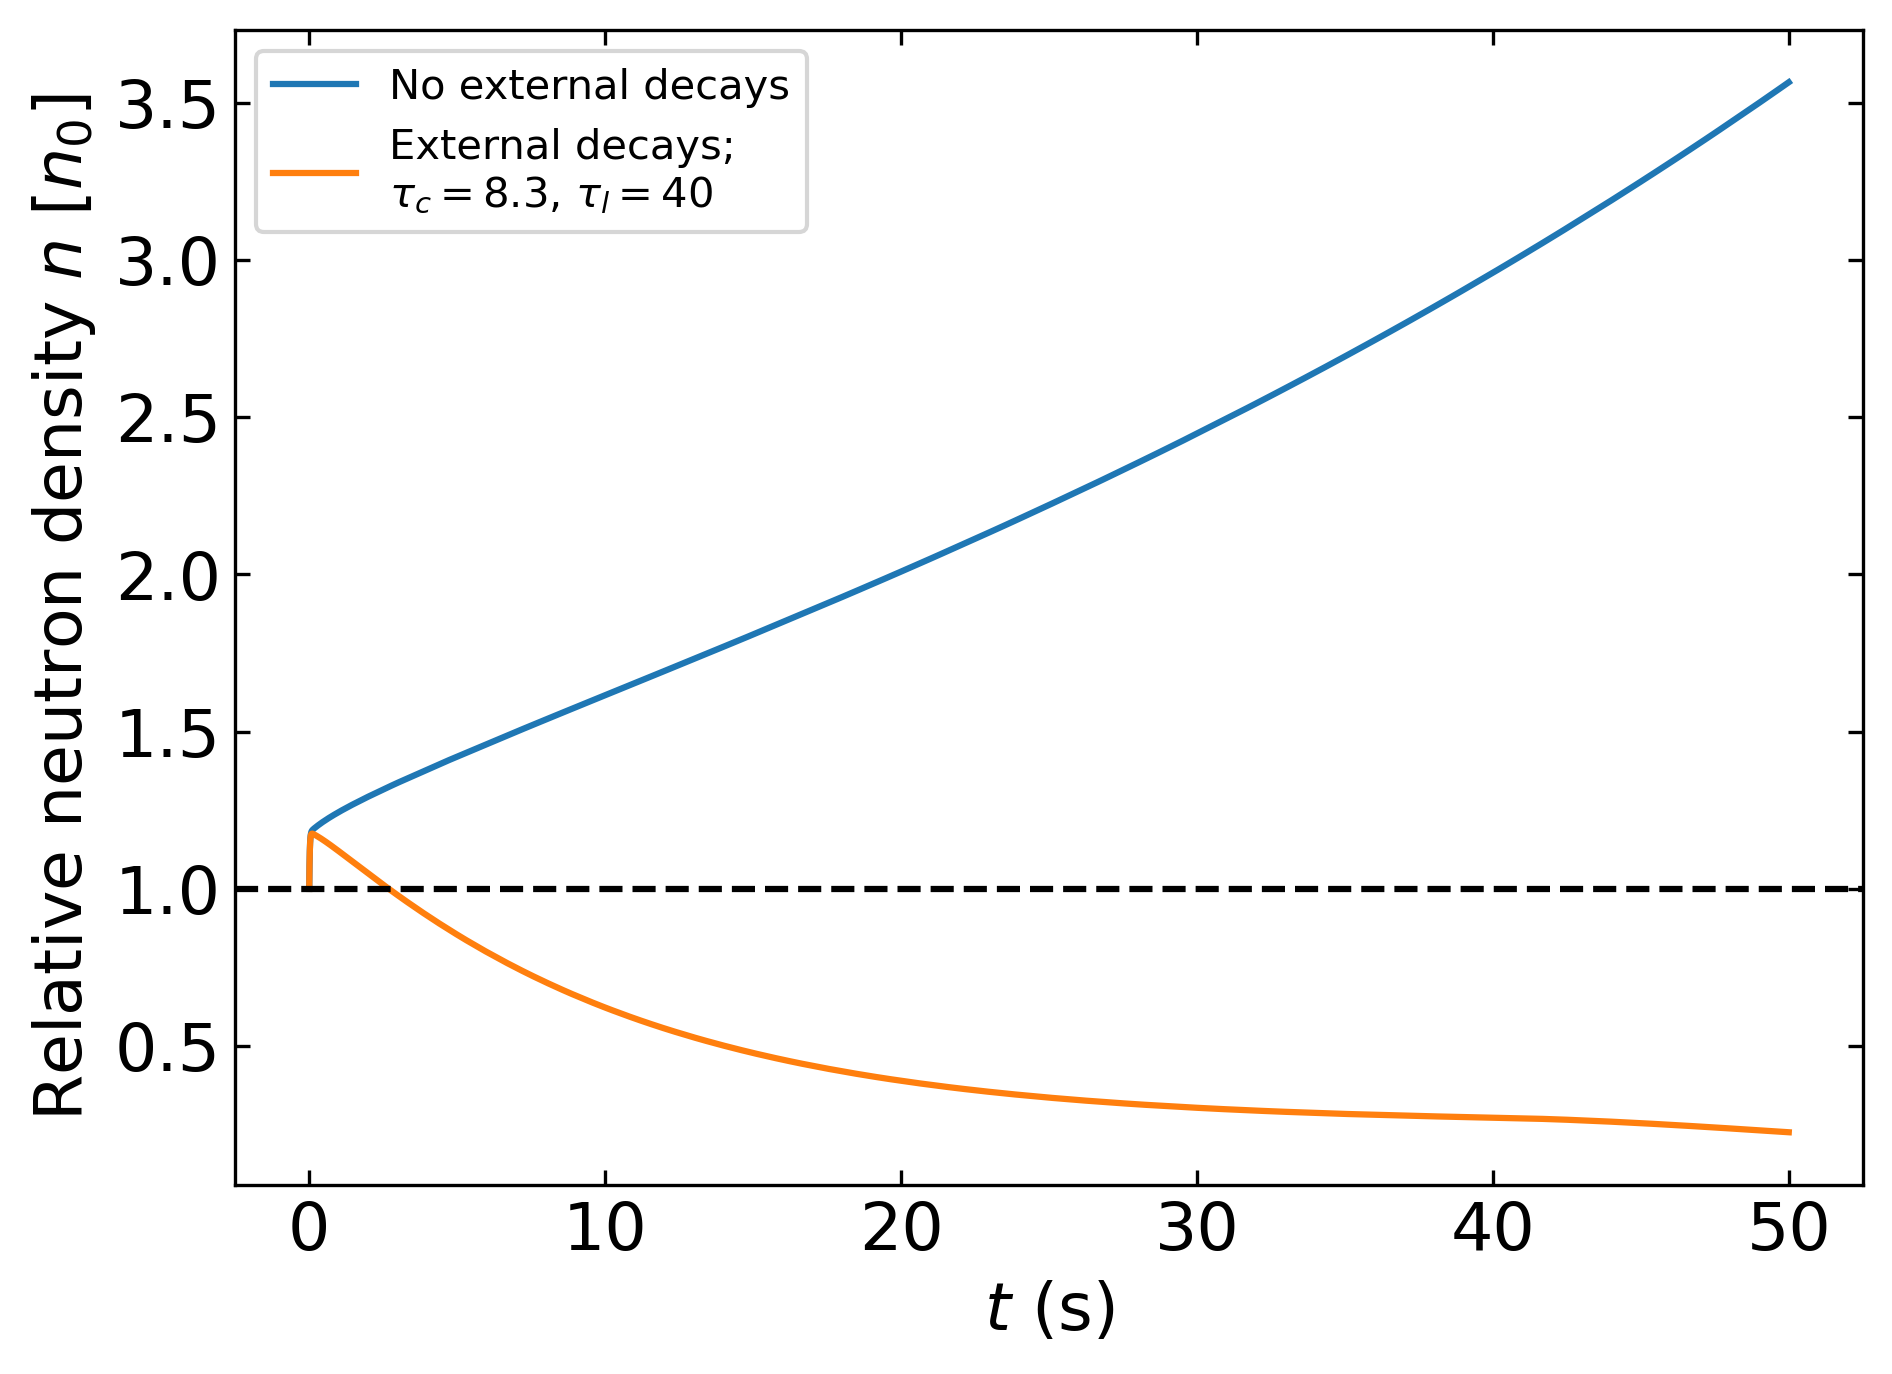

In [231]:
fig, ax = plt.subplots(figsize=(7, 5))

t0 = -5.0
tf = 50.0

ax.plot(T, n_no_delay, label='No external decays')
ax.plot(T, n_delay, label='External decays; \n' + rf'$\tau_c={tau_c}$, $\tau_l={tau_l}$')
# ax.set_xlim(t0, tf)
ax.set_xlabel(r"$t$ (s)")
ax.set_ylabel(r'Relative neutron density $n$ [$n_0$]')
# ax.set_title('Relative neutron densities')
ax.axhline(n_frac0, c='k', ls='--')
ax.legend()

plt.savefig('no_geometry_comparison.png')

In [232]:
import numpy as np
from scipy.integrate import solve_ivp

rho = 0.001                 ## the reactivity change
Lambda = 1e-4               ## the mean neutron generation time (Lambda = l/k)

beta_six_gr = np.array([0.000215, 0.001424, 0.001274, 0.002568, 0.000748, 0.000273])
half_life_six_gr = np.array([55.72, 22.72, 6.22, 2.30, 0.610, 0.230])
lambda_six_gr = np.log(2.)/half_life_six_gr

In [233]:
def six_group_system(t, z, rho, beta_six_gr, Lambda, lambda_six_gr):
        
    n, C1, C2, C3, C4, C5, C6 = z
    
    beta_tot = sum(beta_six_gr)
    All_Cs = [C1,C2, C3, C4, C5, C6]
    
    ## Here, enter the six-group point kinetics equations (i. e. dn/dt, dC1/dt, dC2_dt, ...):
    dn_dt = ((rho - beta_tot)/Lambda) * n + np.sum(lambda_six_gr * All_Cs ) # enter code here
    dC1_dt = (beta_six_gr[0]/Lambda) * n - lambda_six_gr[0]*C1 # enter code here
    dC2_dt = (beta_six_gr[1]/Lambda) * n - lambda_six_gr[1]*C2  # enter code here
    dC3_dt = (beta_six_gr[2]/Lambda) * n - lambda_six_gr[2]*C3 # enter code here
    dC4_dt = (beta_six_gr[3]/Lambda) * n - lambda_six_gr[3]*C4 # enter code here
    dC5_dt = (beta_six_gr[4]/Lambda) * n - lambda_six_gr[4]*C5 # enter code here
    dC6_dt = (beta_six_gr[5]/Lambda) * n - lambda_six_gr[5]*C6 # enter code here
    
    return [dn_dt, dC1_dt, dC2_dt, dC3_dt, dC4_dt, dC5_dt, dC6_dt]

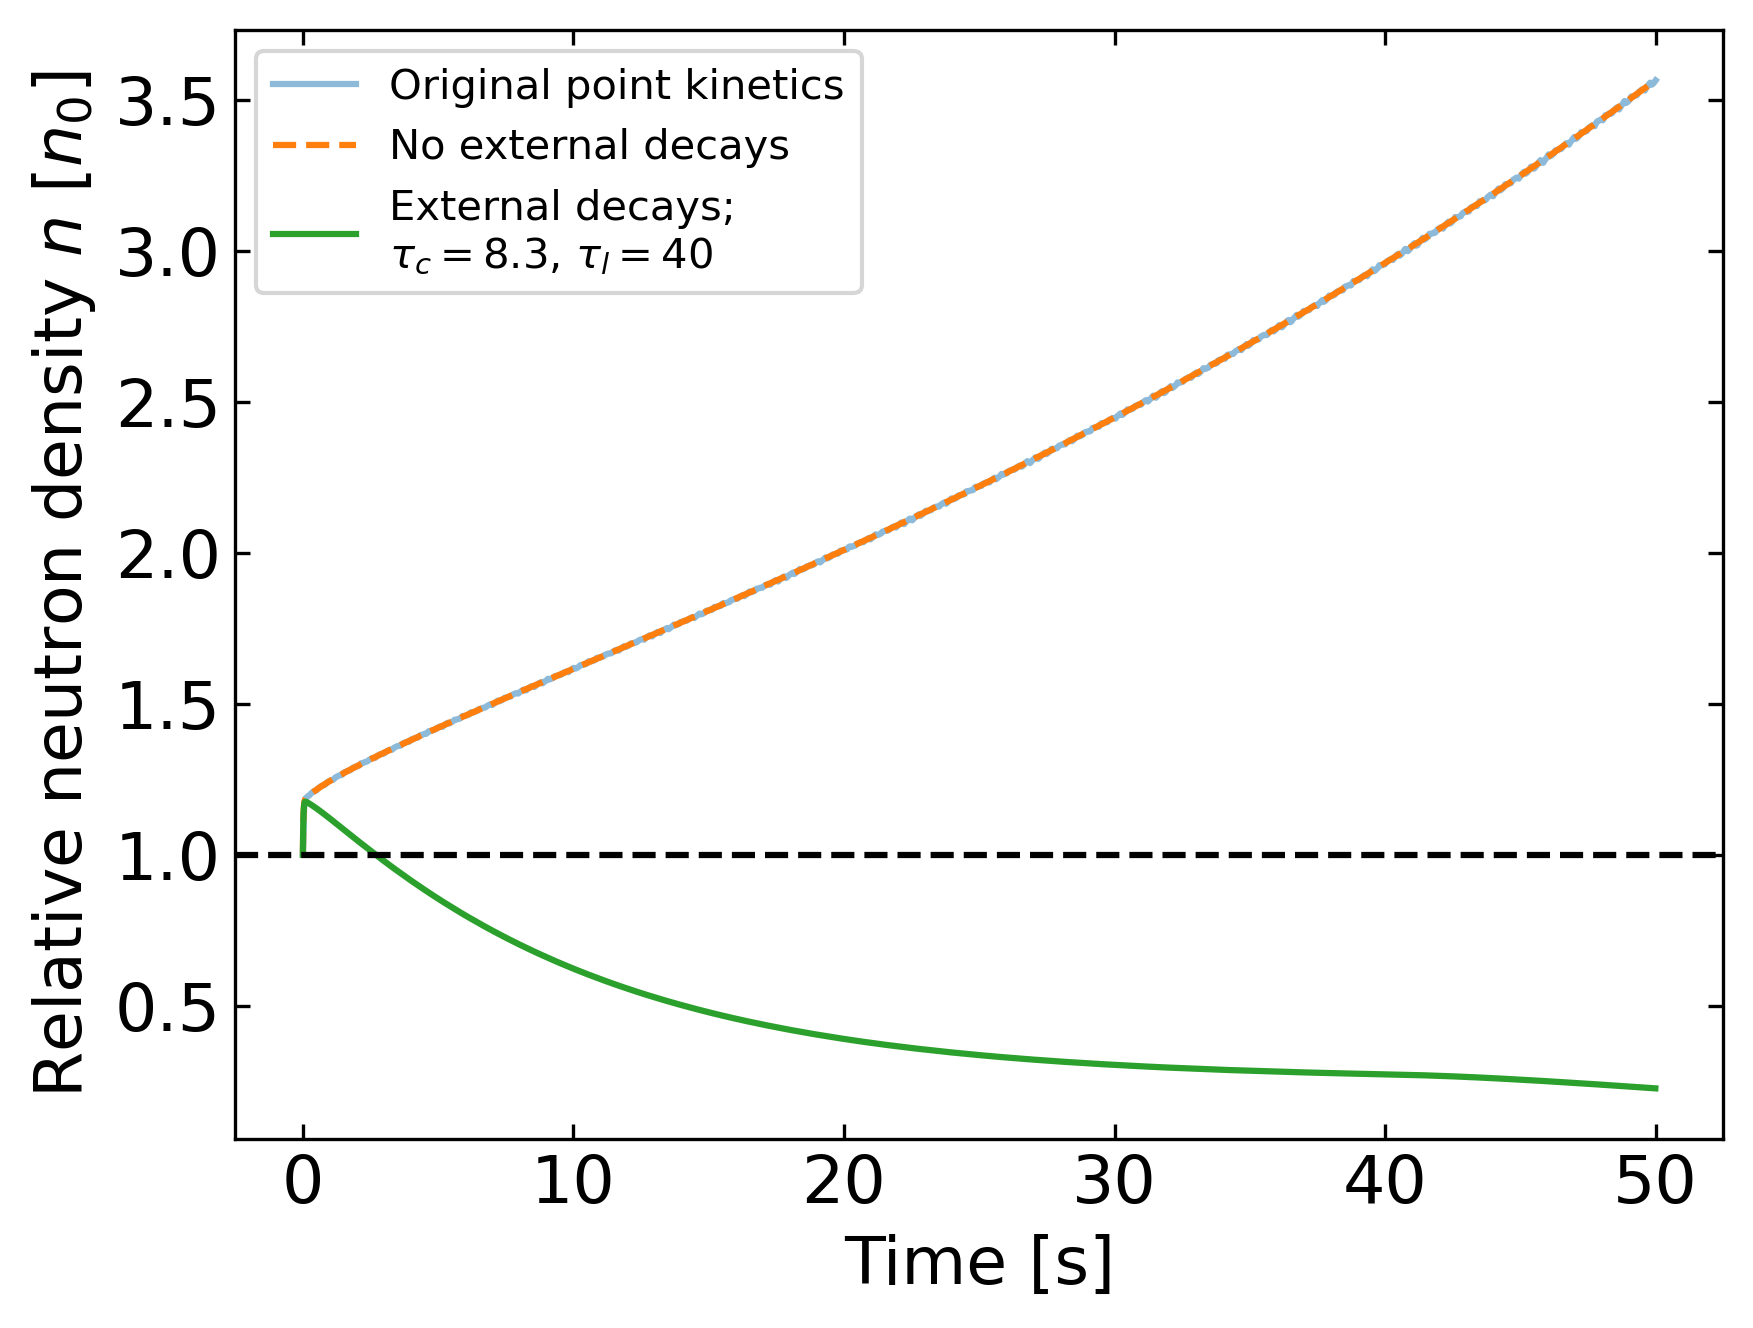

In [234]:
n_0 = 1
C1_0 = beta_six_gr[0]/(lambda_six_gr[0]*Lambda) * n_0 # enter code here
C2_0 = beta_six_gr[1]/(lambda_six_gr[1]*Lambda) * n_0 # enter code here
C3_0 = beta_six_gr[2]/(lambda_six_gr[2]*Lambda) * n_0 # enter code here
C4_0 = beta_six_gr[3]/(lambda_six_gr[3]*Lambda) * n_0 # enter code here
C5_0 = beta_six_gr[4]/(lambda_six_gr[4]*Lambda) * n_0 # enter code here
C6_0 = beta_six_gr[5]/(lambda_six_gr[5]*Lambda) * n_0 # enter code here

t_numerical = np.linspace(0, 50, 1000)                      # solve the problem between t = 0 and t=50 seconds.

solution = solve_ivp(fun=six_group_system, t_span=[t_numerical[0], t_numerical[-1]], y0=[n_0, C1_0, C2_0, C3_0, C4_0, C5_0, C6_0], args=(rho, beta_six_gr, Lambda, lambda_six_gr), dense_output=True)          ## dense_output allows you to solve explicitly for the whole t vector later


solution_six_gr = solution.sol(t_numerical)


n_numerical_six_gr = solution_six_gr[0]
C1_numerical_six_gr = solution_six_gr[1]
C2_numerical_six_gr = solution_six_gr[2]
C3_numerical_six_gr = solution_six_gr[3]
C4_numerical_six_gr = solution_six_gr[4]
C5_numerical_six_gr = solution_six_gr[5]
C6_numerical_six_gr = solution_six_gr[6]

plt.plot(t_numerical, n_numerical_six_gr/n_0, label='Original point kinetics', alpha = 0.5)
plt.plot(T, n_no_delay, label='No external decays', ls = '--' )
plt.plot(T, n_delay, label='External decays; \n' + rf'$\tau_c={tau_c}$, $\tau_l={tau_l}$')
plt.axhline(n_frac0, c='k', ls='--')


plt.xlabel('Time [s]')
plt.ylabel(r'Relative neutron density $n$ [$n_0$]')
plt.legend()
